# Few-shot Annotation Efficiency (Keren)

Reproduces the **few-shot annotation-efficiency** panel of the DeepCell Types paper on the Keren MIBI dataset: macro-F1 as a function of the number of training FOVs (N, log₂ scale), comparing our full-finetune DCT model against the XGBoost and CellSighter from-scratch baselines.

> **Scope.** The scoring step that produces `metrics.csv` (`analysis/score_fewshot.py`) requires a GPU and is **upstream / out of scope** for this notebook. Here we only **plot the saved Keren few-shot metrics** (`data/output/few_shot/keren/metrics.csv`).

Figure follows the **Science Advances 2026** spec via `dct_figures.style`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from dct_figures import paths, style
style.apply_style()

## Few-shot efficiency curve (`fewshot_efficiency_keren`)

caption: Keren annotation-efficiency curve. X = number of training FOVs (log₂ scale), Y = macro-F1 (%). One line per method: our full-finetune (theme color, the only saturated line) vs the XGBoost and CellSighter from-scratch baselines (muted greys). The plot shows the `8–533` FOV subset of the swept grid; the table below records all methods (including the frozen-head variant) at every plotted N.

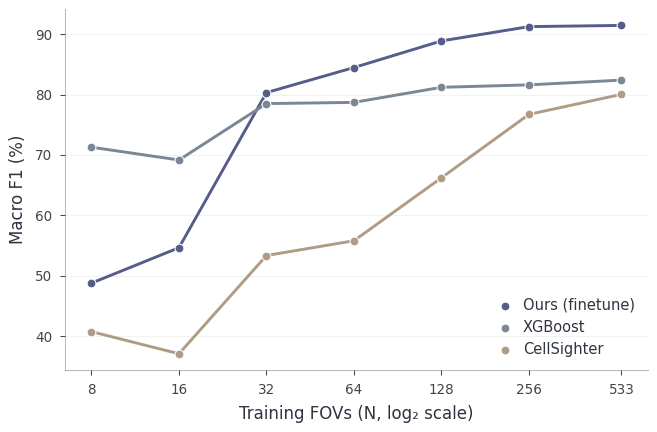

N (FOVs),8,16,32,64,128,256,533
method,,,,,,,
Ours (finetune),48.77,54.64,80.33,84.49,88.89,91.26,91.46
Ours (frozen + head),31.68,43.82,60.24,72.35,79.82,80.56,82.28
XGBoost,71.29,69.17,78.51,78.71,81.21,81.62,82.40
CellSighter,40.74,37.08,53.35,55.79,66.22,76.73,80.05


In [2]:
from dct_figures.style import (
    PAL, apply_style, style_ax, COL_1_5,
    FS_AXIS_LABEL, FS_BODY, FS_TICK,
)

# Plotted methods (ours full-finetune vs the two from-scratch baselines).
# The frozen-head variant is omitted from the headline curve (kept in the
# table below for the record).
_METHODS = ["ours_full", "xgb", "cs"]
_LABELS = {
    "ours_full": "Ours (finetune)",
    "xgb": "XGBoost",
    "cs": "CellSighter",
}
_COLORS = {
    "ours_full": PAL["theme"],  # #565D8B — ours (only saturated/hero line)
    "xgb": PAL["gray"],         # #7B8794 — baseline grey
    "cs": PAL["brown"],         # #B09C85 — muted taupe, second baseline
}

METRIC = "macro_f1"
# Subset of the swept N grid to plot (matches plot_fewshot_curve.py --ns).
KEEP_NS = {8, 16, 32, 64, 128, 256, 533}

metrics_csv = paths.need(paths.OUTPUT / "few_shot/keren/metrics.csv")
df = pd.read_csv(metrics_csv)
df = df[df["n_fov"].isin(KEEP_NS)]
grid = sorted(df["n_fov"].unique())


def series(method):
    d = df[df["method"] == method].sort_values("n_fov")
    return d["n_fov"].tolist(), d[METRIC].tolist()


fig, ax = plt.subplots(figsize=(COL_1_5, 3.0))
for m in _METHODS:
    xs, ys = series(m)
    if not xs:
        continue
    ax.plot(xs, ys, "-", color=_COLORS[m], linewidth=1.4, zorder=2)
    ax.scatter(xs, ys, s=18, color=_COLORS[m], edgecolor="white",
               linewidth=0.5, zorder=3, label=_LABELS.get(m, m))

ax.set_xscale("log", base=2)
ax.set_xticks(grid)
ax.set_xticklabels([str(n) for n in grid], fontsize=FS_TICK)
ax.minorticks_off()
ax.set_xlabel("Training FOVs (N, log₂ scale)", fontsize=FS_AXIS_LABEL)
ax.set_ylabel("Macro F1 (%)", fontsize=FS_AXIS_LABEL)
ax.legend(fontsize=FS_BODY, loc="lower right")
style_ax(ax, grid_axis="y")
fig.tight_layout()
plt.show()

# Results table (all methods incl. frozen-head, for the record).
_full_labels = {**_LABELS, "ours_frozen": "Ours (frozen + head)"}
tbl = (df.pivot_table(index="method", columns="n_fov", values=METRIC)
         .reindex(["ours_full", "ours_frozen", "xgb", "cs"])
         .rename(index=_full_labels)
         .round(2))
tbl.columns.name = "N (FOVs)"
tbl.index.name = "method"
tbl